# Part 1a: Load and Export Impedance Data

**Reference**: The data were downloaded from https://mt3dinv4.mtnet.info/Secret_model.html

**IMPORTANT:**

* The coordinates for the noise added and noise free files are slightly different
* The frequencies for the noise free at highest to lowest, but are lowest to highest for the noise added
* The elevation in the data files is 0. We need to do linear interpolation from the topography to assign elevation

**WHAT THE NOTEBOOK DOES:**

1. Load the noise free data from all the EDI files
2. Organize it into a single array (n_freq, n_comp, n_loc)
3. Assign elevations using linear interpolation from the topography
4. Output data in its original format (NED and +iwt)

**Coordinates:** For the purpose of geographic location, the sites have been transposed assuming a UTM Zone of 12N. Thus the SW site at (-12.5,12.5) has latitude and longitude of (00:00:00.4068; -115:29:19.8750), which maps into the middle of the Pacific Ocean.

*I TRIED TO CONVERT FROM LAT LON BUT MY MOST SOUTHWEST SITE WASN'T EXACTLY (-12.5,12.5).*

**What is the data convention?**

From looking at the original data:

* ZXY is in the upper-right coordinate of the complex plane (phase $\approx$45)
* ZYX is in the lower-left coordinate of the complex plane (phase $\approx$-135)

This means the original data convention is:

* X, Y, Z is Northing-Easting-Down
* A $+i\omega t$ Fourier convention is used

In [1]:
from simpeg.electromagnetics import natural_source as nsem
from simpeg.utils import plot2Ddata
from discretize.utils import ndgrid, mkvc

import numpy as np
from scipy.interpolate import LinearNDInterpolator
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import ticker
from matplotlib.colors import LogNorm
from matplotlib.ticker import FormatStrFormatter
import os, sys, re, utm

from ipywidgets import (
    interact,
    interactive,
    IntSlider,
    widget,
    FloatText,
    FloatSlider,
    Checkbox,
    fixed,
)

plt.rcParams.update({'font.size': 18})

topo_file = './elevation/elevation.txt'
data_dir = './MT3DINV4S_noisefree_EDI/'  # './MT3DINV4S_withnoise_EDI/'
out_dir = './part_1_outputs/'

# What data components do you want to extract?
components = [
    'ZXXR', 'ZXXI', 'ZXYR', 'ZXYI', 'ZYXR', 'ZYXI', 'ZYYR', 'ZYYI',
    'RHOXY', 'RHOYX', 'PHSXY', 'PHSYX',
    'TXR', 'TXI', 'TYR', 'TYI'
]
n_comp = len(components)

# bs_location = np.array([557355.62, 6465992.96, 484.55])

In [2]:
if not os.path.exists(out_dir):
    os.mkdir(out_dir)

## Load Topography

In [3]:
topo_xyz = np.loadtxt(topo_file)

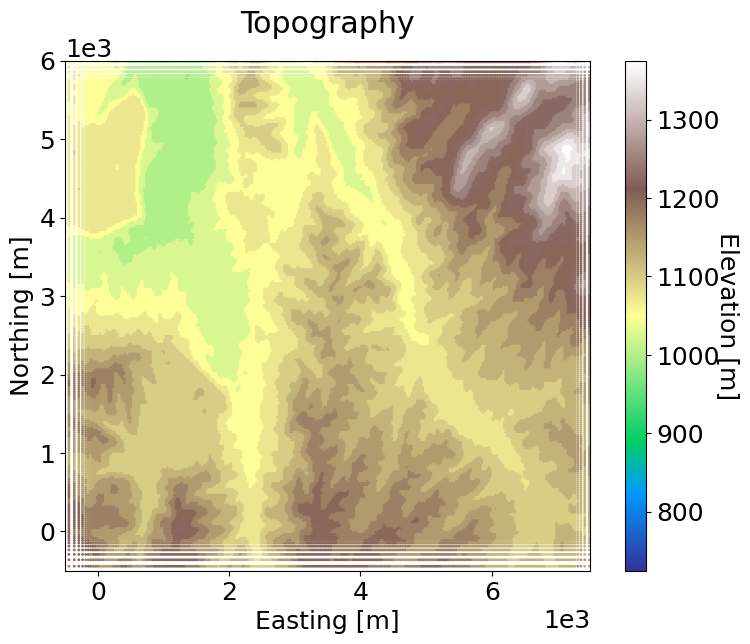

In [4]:
# Plot Topography and Area of Interest
fig = plt.figure(figsize=(7, 6))

ax11 = fig.add_axes([0.1, 0.05, 0.75, 0.85])
norm1 = mpl.colors.Normalize(vmin=topo_xyz[:, 2].min(), vmax=topo_xyz[:, 2].max())
ax11.scatter(topo_xyz[:, 0], topo_xyz[:, 1], 1, c=topo_xyz[:, 2], cmap=mpl.cm.terrain, norm=norm1)
ax11.ticklabel_format(axis='both', scilimits=(0, 3))
ax11.set_xlabel('Easting [m]')
ax11.set_ylabel('Northing [m]')
ax11.set_title('Topography', pad=20)

ax11.set_xlim([-500, 7500])
ax11.set_ylim([-500, 6000])

ax12 = fig.add_axes([0.9, 0.05, 0.03, 0.85])

cbar1 = mpl.colorbar.ColorbarBase(ax12, norm=norm1, orientation="vertical", cmap=mpl.cm.terrain)
cbar1.set_label("Elevation [m]", rotation=270, labelpad=15)

## Load EDI Files

Data array will be organized (n_freq, n_comp, n_loc)

In [5]:
fnames = [f for f in os.listdir(data_dir)]
n_loc = len(fnames)

In [6]:
def load_edi_file(fname):

    fid = open(data_dir + fname, 'r')
    lines = fid.readlines()
    fid.close()

    # EXTRACT LOCATION AND CONVERT TO UTM
    ind = np.where([x[:7] == 'REFLAT=' for x in lines])[0][0]  # Find line
    lat = re.split(r'[=:\n]', lines[ind])  # split for deg, min, sec
    pm = -1. if lat[1][0] == '-' else 1.  # plus or minus
    lat = float(lat[1]) + pm*float(lat[2])/60 + pm*float(lat[3])/3600  # convert to deg
    
    ind = np.where([x[:8] == 'REFLONG=' for x in lines])[0][0]
    lon = re.split(r'[=:\n]', lines[ind])
    pm = -1. if lon[1][0] == '-' else 1.
    lon = float(lon[1]) + pm*float(lon[2])/60 + pm*float(lon[3])/3600
    
    # Convert to local UTM
    east, north, _, _ = utm.from_latlon(
        lat, lon, force_zone_number=12, force_zone_letter='N'
    )
    
    ind = np.where([x[:8] == 'REFELEV=' for x in lines])[0][0]
    elev = re.split(r'[=:\n]', lines[ind])
    elev = float(elev[1])

    # TRUNCATE EVERYTHING BEFORE THE LINE WITH FREQ
    ind = np.where([x[:5] == '>FREQ' for x in lines])[0][0]
    lines = lines[ind:]

    # EXTRACT THE FREQUENCIES
    ind = np.where(['FREQ' in x for x in lines])[0][0]
    
    ind = ind + 1
    temp = []
    while lines[ind][0] != '>':
        temp.append(lines[ind].split())
        ind = ind + 1
    temp = [np.array([float(x) for x in y]) for y in temp]
    
    freq = np.hstack(temp)
    n_freq =  len(freq)

    # EXTRACT THE DATA VALUES
    array = np.zeros((n_freq, n_comp))
    
    for ii, comp in enumerate(components):
    
        # Find the line where is starts
        ind = np.where([comp in x for x in lines])[0][0]
        ind = ind + 1
        
        # Get all the lines and turn into a numpy array
        temp = []
        while lines[ind][0] != '>':
            temp.append(lines[ind].split())
            ind = ind + 1
        temp = [np.array([float(x) for x in y]) for y in temp]
    
        array[:, ii] = np.hstack(temp)

    # Frequencies were ordered highest to lowest
    freq = np.flipud(freq)
    array = np.flip(array, axis=0)
    
    return east, north, elev, freq, array

In [7]:
n_files = len(fnames)
easting = n_files * [None]
northing = n_files * [None]
elevation = n_files * [None]
frequencies = n_files * [None]
data_array = n_files * [None]

for ii, fname in enumerate(fnames):

    east, north, elev, freq, array = load_edi_file(fname)

    easting[ii] = east
    northing[ii] = north
    elevation[ii] = elev
    frequencies[ii] = freq
    data_array[ii] = array

xyz = np.c_[
    np.array(easting),
    np.array(northing),
    np.array(elevation)
]
frequencies = frequencies[0]  # All sites have same frequencies
n_freq = len(frequencies)
data_array = np.stack(data_array, axis=2)

## Assign Elevation

In [8]:
interp_fcn = LinearNDInterpolator(topo_xyz[:, :2], topo_xyz[:, -1])
elevations = interp_fcn(xyz[:, :2])
xyz[:, 2] = elevations

## Plot Data

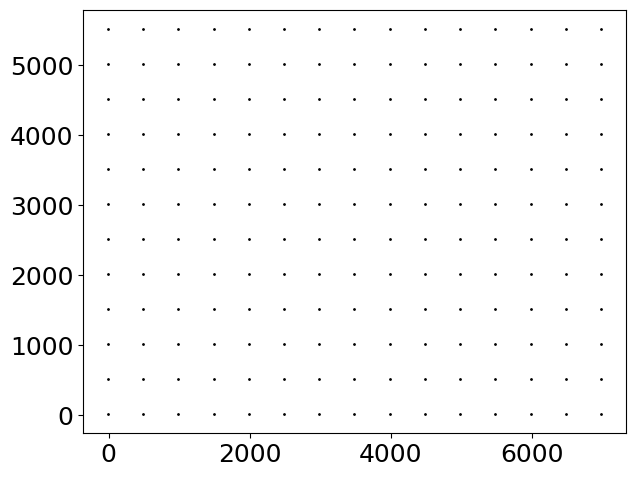

In [9]:
fig = plt.figure(figsize=(7, 5.5))
ax = fig.add_subplot(111)
ax.scatter(xyz[:, 0], xyz[:, 1], 1, 'k')
# ax.scatter(bs_location[0], bs_location[1], 4, 'k')

## Plot Soundings

In [10]:
def plot_site(ind_comp, ind_loc, plot_all=True):

    ind_comp = ind_comp - 1
    ind_loc = ind_loc - 1
    
    fig = plt.figure(figsize=(7, 5))
    ax = fig.add_axes([0.1, 0.1, 0.85, 0.85])
    if plot_all:
        plotting_data = data_array[:, ind_comp, :]
        if components[ind_comp] in ['RHOXY', 'RHOYX']:
            ax.loglog(frequencies, plotting_data, '-o')
        else:
            ax.semilogx(frequencies, plotting_data, '-o')
        ax.set_title(components[ind_comp])
        
    else:
        ind_comp = 2 * (ind_comp // 2 )
        plotting_1 = data_array[:, ind_comp, ind_loc]
        plotting_2 = data_array[:, ind_comp+1, ind_loc]
        
        if components[ind_comp] in ['RHOXY', 'RHOYX']:
            ax.loglog(frequencies, plotting_1, 'b-o')
            ax.loglog(frequencies, plotting_2, 'r-o')
            ax.legend(['RHOXY', 'RHOYX'])
        else:
            ax.semilogx(frequencies, plotting_1, 'b-o')
            ax.semilogx(frequencies, plotting_2, 'r-o')
            ax.legend(['Real', 'Imag'])

        ax.set_title(components[ind_comp][:3])

    ax.set_xlabel('Frequency (Hz)')
    ax.grid(which="both")
    

def PlottingSite():

    i = interact(
        plot_site,
        ind_comp=IntSlider(
            min=1,
            max=n_comp,
            value=1,
            step=1,
            continuous_update=True,
            description="Component",
        ),
        ind_loc=IntSlider(
            min=1,
            max=n_loc,
            value=1,
            step=1,
            continuous_update=True,
            description="Location",
        ),
        plot_all=Checkbox(
            value=True,
            description="Plot All"
        )
    )
    
    return i

In [11]:
PlottingSite()

interactive(children=(IntSlider(value=1, description='Component', max=16, min=1), IntSlider(value=1, descripti…

<function __main__.plot_site(ind_comp, ind_loc, plot_all=True)>

## Plot Data Maps

In [12]:
cmap = mpl.cm.Spectral

def plot_data(ind_comp, ind_freq):

    ind_comp = ind_comp - 1
    ind_freq = ind_freq - 1
    
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_axes([0.1, 0.1, 0.75, 0.85])
    cax = fig.add_axes([0.9, 0.1, 0.03, 0.85])

    plotting_data = data_array[ind_freq, ind_comp, :]

    if components[ind_comp] in ['RHOXY', 'RHOYX']:
        norm = mpl.colors.LogNorm(vmin=plotting_data.min(), vmax=plotting_data.max())
    else:
        norm = mpl.colors.Normalize(vmin=plotting_data.min(), vmax=plotting_data.max())

    ax.scatter(xyz[:, 0], xyz[:, 1], 108, c=plotting_data, cmap=cmap, norm=norm)

    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    ax.set_title("{}: {} Hz".format(components[ind_comp], frequencies[ind_freq]))
    
    cbar = mpl.colorbar.ColorbarBase(
        cax, norm=norm, orientation="vertical", cmap=cmap
    )

    plt.show(fig)

def PlotData():

    i = interact(
        plot_data,
        ind_comp=IntSlider(
            min=1,
            max=n_comp,
            value=1,
            step=1,
            continuous_update=True,
            description="Component",
        ),
        ind_freq=IntSlider(
            min=1,
            max=n_freq,
            value=1,
            step=1,
            continuous_update=True,
            description="Frequency",
        )
    )
    
    return i

In [13]:
PlotData()

interactive(children=(IntSlider(value=1, description='Component', max=16, min=1), IntSlider(value=1, descripti…

<function __main__.plot_data(ind_comp, ind_freq)>

In [14]:
# Extract the MT impedance data
mt_array = data_array[:, :8, :]
tipper_array = data_array[:, -4:, :]

## Phase Tensor Plot

In [31]:
def plot_phase_tensors(ind_freq):

    ind_freq = ind_freq - 1

    # Get entries for X and Y
    x11, x12, x21, x22 = mt_array[ind_freq, 0, :], mt_array[ind_freq, 2, :], mt_array[ind_freq, 4, :], mt_array[ind_freq, 6, :]
    y11, y12, y21, y22 = mt_array[ind_freq, 1, :], mt_array[ind_freq, 3, :], mt_array[ind_freq, 5, :], mt_array[ind_freq, 7, :]
    
    # Compute entries for phase tensor
    detx = x11 * x22 - x21 * x12
    phi11 = (x22 * y11 - x12 * y21) / detx
    phi12 = (x22 * y12 - x12 * y22) / detx
    phi21 = (x11 * y21 - x21 * y11) / detx
    phi22 = (x11 * y22 - x21 * y12) / detx
    
    # Get phi max and phi min
    phi_1 = (phi11 + phi22) / 2  # Tr(phi) / 2
    phi_2 = np.sqrt(phi11 * phi22 - phi12 * phi21)  # sqrt(det(phi))
    phi_3 = (phi12 - phi21) / 2  # sk(phi) / 2
    phi_min = np.sqrt(phi_1**2 + phi_3**2) - np.sqrt(phi_1**2 + phi_3**2 - phi_2**2)
    phi_max = np.sqrt(phi_1**2 + phi_3**2) + np.sqrt(phi_1**2 + phi_3**2 - phi_2**2)
    
    # Get angles
    beta = 0.5 * np.arctan(phi_3 / phi_1)
    alpha = 0.5 * np.arctan((phi12 + phi21) / (phi11 - phi22))

    scale = 15.
    widths = scale * phi_max
    heights = scale * phi_min
    angles = np.rad2deg(alpha - beta)
    
    # 2. Plot the collection
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_axes([0.1, 0.1, 0.85, 0.85])
    ec = mpl.collections.EllipseCollection(
        widths,
        heights,
        angles,
        offsets=xyz[:, :2], 
        transOffset=ax.transData,
        facecolor='red',
        edgecolor='black',
        linewidth=1,
        alpha=0.7
    )
    ax.add_collection(ec)
    
    ax.quiver(xyz[:, 0], xyz[:, 1], np.cos(alpha-beta), np.sin(alpha-beta), color='b', width=0.0025)
    
    # 3. Format the plot
    ax.set_xlim([xyz[:, 0].min() - 250, xyz[:, 0].max() + 250])
    ax.set_ylim([xyz[:, 1].min() - 250, xyz[:, 1].max() + 250])
    ax.set_title('Phase Plot: {} Hz'.format(frequencies[ind_freq]))

def PlotPhaseTensors():

    i = interact(
        plot_phase_tensors,
        ind_freq=IntSlider(
            min=1,
            max=n_freq,
            value=11,
            step=1,
            continuous_update=True,
            description="Frequency",
        )
    )
    
    return i

In [32]:
PlotPhaseTensors()

interactive(children=(IntSlider(value=1, description='Frequency', max=35, min=1), Output()), _dom_classes=('wi…

<function __main__.plot_phase_tensors(ind_freq)>

## Plot Wiese Vectors

In [29]:
def plot_wiese_vectors(ind_freq):

    ind_freq = ind_freq - 1

    scale = 5.

    vx_real = scale * tipper_array[ind_freq, 2, :]
    vy_real = scale * tipper_array[ind_freq, 0, :]

    vx_imag = scale * -tipper_array[ind_freq, 3, :]  # Im[Tzy]
    vy_imag = scale * -tipper_array[ind_freq, 1, :]  # Im[Tzx]
    
    fig = plt.figure(figsize=(15, 6))
    ax1 = fig.add_axes([0.1, 0.1, 0.4, 0.85])
    ax2 = fig.add_axes([0.6, 0.1, 0.4, 0.85])
    
    ax1.quiver(xyz[:, 0], xyz[:, 1], vx_real, vy_real, color='b', width=0.0025)
    ax2.quiver(xyz[:, 0], xyz[:, 1], vx_imag, vy_imag, color='r', width=0.0025)
    
    ax1.set_xlim([xyz[:, 0].min() - 250, xyz[:, 0].max() + 250])
    ax1.set_ylim([xyz[:, 1].min() - 250, xyz[:, 1].max() + 250])
    ax1.set_title('Wiese Vectors: {} Hz'.format(frequencies[ind_freq]))

    ax2.set_xlim([xyz[:, 0].min() - 250, xyz[:, 0].max() + 250])
    ax2.set_ylim([xyz[:, 1].min() - 250, xyz[:, 1].max() + 250])
    ax2.set_title('Wiese Vectors: {} Hz'.format(frequencies[ind_freq]))
    
    fig.show()

def PlotWieseVectors():

    i = interact(
        plot_wiese_vectors,
        ind_freq=IntSlider(
            min=1,
            max=n_freq,
            value=1,
            step=1,
            continuous_update=True,
            description="Frequency",
        )
    )
    
    return i

In [30]:
PlotWieseVectors()

interactive(children=(IntSlider(value=1, description='Frequency', max=35, min=1), Output()), _dom_classes=('wi…

<function __main__.plot_wiese_vectors(ind_freq)>

## Processing to Remove Static Shift?

## Output Data (Just Impedances)

In [19]:
np.save(out_dir + 'locations_mt.npy', xyz)
np.save(out_dir + 'frequencies_mt.npy', frequencies)
np.save(out_dir + 'data_mt.npy', mt_array)

In [20]:
# simpeg_array = np.zeros((n_freq, n_comp, n_loc))

# simpeg_array[:, 0, :] = data_array[:, 6, :]  # yy --> xx
# simpeg_array[:, 1, :] = data_array[:, 7, :]

# simpeg_array[:, 2, :] = data_array[:, 4, :]  # yx --> xy
# simpeg_array[:, 3, :] = data_array[:, 5, :]

# simpeg_array[:, 4, :] = data_array[:, 2, :]  # xy --> yx
# simpeg_array[:, 5, :] = data_array[:, 3, :]

# simpeg_array[:, 6, :] = data_array[:, 0, :]  # xx --> yy
# simpeg_array[:, 7, :] = data_array[:, 1, :]